In [34]:
import pandas as pd
import numpy as np

file_path = "kaggle_survey_2017_2021.csv" 
raw = pd.read_csv(file_path)

print("Original shape:", raw.shape)
raw.head(3)

C:\Users\ziyad\AppData\Local\Temp\ipykernel_4164\2822000530.py:5: DtypeWarning: Columns (0,1,8,9,10,11,12,13,14,15,16,17,18,19,20,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,

Original shape: (106302, 293)


,-,Time from Start to Finish (seconds),Q1,Q2,Q3,Q4,Q5,Q6,Q7_Part_1,Q7_Part_2,...,Q38_B_Part_1,Q38_B_Part_2,Q38_B_Part_3,Q38_B_Part_4,Q38_B_Part_5,Q38_B_Part_6,Q38_B_Part_7,Q38_B_Part_9,Q38_B_Part_11,Q38_B_OTHER
0,Year,Duration (in seconds),What is your age (# years)?,What is your gender? - Selected Choice,In which country do you currently reside?,What is the highest level of formal education ...,Select the title most similar to your current ...,For how many years have you been writing code ...,What programming languages do you use on a reg...,What programming languages do you use on a reg...,...,"In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor..."
1,2021,910,50-54,Man,India,Bachelorâ€™s degree,Other,5-10 years,Python,R,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021,784,50-54,Man,Indonesia,Masterâ€™s degree,Program/Project Manager,20+ years,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [35]:
df = raw.drop(index=0).reset_index(drop=True).copy()

df.columns = df.columns.astype(str).str.strip().str.replace(r"\s+", " ", regex=True)
df = df.replace(["", "NA", "N/A", "None", "nan", "NaN"], np.nan)

print("Shape after cleaning:", df.shape)
df.head()

C:\Users\ziyad\AppData\Local\Temp\ipykernel_4164\1694498107.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(["", "NA", "N/A", "None", "nan", "NaN"], np.nan)


Shape after cleaning: (106301, 293)


,-,Time from Start to Finish (seconds),Q1,Q2,Q3,Q4,Q5,Q6,Q7_Part_1,Q7_Part_2,...,Q38_B_Part_1,Q38_B_Part_2,Q38_B_Part_3,Q38_B_Part_4,Q38_B_Part_5,Q38_B_Part_6,Q38_B_Part_7,Q38_B_Part_9,Q38_B_Part_11,Q38_B_OTHER
0,2021,910,50-54,Man,India,Bachelorâ€™s degree,Other,5-10 years,Python,R,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021,784,50-54,Man,Indonesia,Masterâ€™s degree,Program/Project Manager,20+ years,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021,924,22-24,Man,Pakistan,Masterâ€™s degree,Software Engineer,1-3 years,Python,NaN,...,NaN,NaN,NaN,NaN,TensorBoard,NaN,NaN,NaN,NaN,NaN
3,2021,575,45-49,Man,Mexico,Doctoral degree,Research Scientist,20+ years,Python,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2021,781,45-49,Man,India,Doctoral degree,Other,< 1 years,Python,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [36]:
print("Columns:", len(df.columns))
print("\nData types count:\n", df.dtypes.value_counts())

missing_pct = df.isna().mean().sort_values(ascending=False)
print("\nColumns with > 50% missing values:", (missing_pct > 0.5).sum())

missing_pct.head(15)

Columns: 293

Data types count:
 object     276
float64     17
Name: count, dtype: int64

Columns with > 50% missing values: 278


Q38_B_Part_11    1.0
Q34_B_Part_16    1.0
Q9_Part_12       1.0
Q7_Part_12       1.0
Q14_Part_11      1.0
Q16_Part_17      1.0
Q10_Part_16      1.0
Q32_B_Part_20    1.0
Q19_Part_5       1.0
Q18_Part_6       1.0
Q17_Part_11      1.0
Q36_B_Part_7     1.0
Q27_B_Part_11    1.0
Q40_Part_11      1.0
Q34_A_Part_16    1.0
dtype: float64

In [37]:
unique_counts = df.nunique(dropna=True).sort_values(ascending=False)
print("Top 10 columns by unique values:\n", unique_counts.head(10))

part_cols = [c for c in df.columns if "Part" in c or "_Part_" in c or "Part_" in c]
print(f"\nFound {len(part_cols)} multi-choice columns (e.g., Q7_Part_1, Q9_Part_1, ...)")
print(part_cols[:15])

Top 10 columns by unique values:
 Time from Start to Finish (seconds)    12777
Q3                                        77
Q25                                       47
Q5                                        35
Q33                                       24
Q8                                        22
Q6                                        20
Q20                                       19
Q35                                       17
Q15                                       15
dtype: int64

Found 245 multi-choice columns (e.g., Q7_Part_1, Q9_Part_1, ...)
['Q7_Part_1', 'Q7_Part_2', 'Q7_Part_3', 'Q7_Part_4', 'Q7_Part_5', 'Q7_Part_6', 'Q7_Part_7', 'Q7_Part_8', 'Q7_Part_9', 'Q7_Part_10', 'Q7_Part_11', 'Q7_Part_12', 'Q9_Part_1', 'Q9_Part_2', 'Q9_Part_3']


In [38]:
df = df.applymap(lambda x: str(x).replace("â€™", "’") if isinstance(x, str) else x)

threshold = 0.8
df = df.loc[:, df.isna().mean() < threshold]

print("Shape after dropping mostly-empty columns:", df.shape)

C:\Users\ziyad\AppData\Local\Temp\ipykernel_4164\958974228.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: str(x).replace("â€™", "’") if isinstance(x, str) else x)


Shape after dropping mostly-empty columns: (106301, 42)


In [39]:
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.strip().str.capitalize()

df.head()

,-,Time from Start to Finish (seconds),Q1,Q2,Q3,Q4,Q5,Q6,Q7_Part_1,Q7_Part_3,...,Q24_Part_1,Q24_Part_3,Q25,Q26,Q40_Part_1,Q40_Part_3,Q41,Q42_Part_4,Q42_Part_6,Q42_Part_8
0,2021,910,50-54,Man,India,Bachelor’s degree,Other,5-10 years,Python,Nan,...,Nan,Nan,"25,000-29,999",$100-$999,Coursera,Kaggle learn courses,"Local development environments (rstudio, jupyt...","Kaggle (notebooks, forums, etc)","Youtube (kaggle youtube, cloud ai adventures, ...","Blogs (towards data science, analytics vidhya,..."
1,2021,784,50-54,Man,Indonesia,Master’s degree,Program/project manager,20+ years,Nan,Sql,...,Nan,Nan,"60,000-69,999",$0 ($usd),Nan,Kaggle learn courses,"Advanced statistical software (spss, sas, etc.)",Nan,Nan,Nan
2,2021,924,22-24,Man,Pakistan,Master’s degree,Software engineer,1-3 years,Python,Nan,...,Nan,Nan,$0-999,$0 ($usd),Nan,Nan,"Basic statistical software (microsoft excel, g...","Kaggle (notebooks, forums, etc)","Youtube (kaggle youtube, cloud ai adventures, ...",Nan
3,2021,575,45-49,Man,Mexico,Doctoral degree,Research scientist,20+ years,Python,Nan,...,Nan,Nan,"30,000-39,999",$0 ($usd),Coursera,Nan,"Local development environments (rstudio, jupyt...",Nan,"Youtube (kaggle youtube, cloud ai adventures, ...","Blogs (towards data science, analytics vidhya,..."
4,2021,781,45-49,Man,India,Doctoral degree,Other,< 1 years,Python,Nan,...,Analyze and understand data to influence produ...,Build prototypes to explore applying machine l...,"30,000-39,999","$1000-$9,999",Nan,Kaggle learn courses,"Local development environments (rstudio, jupyt...",Nan,Nan,Nan


In [40]:
from sklearn.preprocessing import LabelEncoder

cat_cols = ["Q1", "Q2", "Q3", "Q4", "Q5", "Q6"]
encoders = {}

for col in cat_cols:
    if col in df.columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        encoders[col] = le
        print(f"Encoded {col} - {len(le.classes_)} unique values")

df[cat_cols].head()

Encoded Q1 - 12 unique values
Encoded Q2 - 10 unique values
Encoded Q3 - 78 unique values
Encoded Q4 - 13 unique values
Encoded Q5 - 36 unique values
Encoded Q6 - 21 unique values


,Q1,Q2,Q3,Q4,Q5,Q6
0,7,3,26,1,20,10
1,7,3,27,6,25,4
2,1,3,47,6,33,2
3,6,3,38,2,28,4
4,6,3,26,2,20,13


In [41]:
before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]

print(f"Removed {before - after} duplicate rows")
print("New shape:", df.shape)

Removed 4454 duplicate rows
New shape: (101847, 42)


In [42]:
placeholders = ["?", "none", "na", "nan", "null", "n/a", "other", "prefer not to say"]

df = df.applymap(
    lambda x: np.nan if isinstance(x, str) and x.strip().lower() in placeholders else x
)

print("Missing values after cleaning:")
print(df.isna().sum().sort_values(ascending=False).head(10))

C:\Users\ziyad\AppData\Local\Temp\ipykernel_4164\3687694803.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(


Missing values after cleaning:
Q24_Part_3    80476
Q9_Part_2     80292
Q40_Part_3    79213
Q12_Part_1    78863
Q9_Part_5     77996
Q10_Part_2    77643
Q42_Part_8    77595
Q42_Part_6    77005
Q10_Part_1    75461
Q9_Part_3     74778
dtype: int64


In [43]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in num_cols:
    invalid = df[col].apply(lambda x: isinstance(x, (int, float)) and x < 0).sum()
    if invalid > 0:
        print(f"{col}: {invalid} negative values found")

df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Q1,101847.0,2.767917,2.265660,0.0,1.0,2.0,4.0,11.0
Q2,101847.0,2.947578,2.049601,0.0,2.0,2.0,3.0,9.0
Q3,101847.0,40.059138,23.012645,0.0,26.0,34.0,61.0,77.0
Q4,101847.0,4.147319,3.077911,0.0,1.0,5.0,6.0,12.0
Q5,101847.0,20.095231,12.214383,0.0,9.0,20.0,33.0,35.0
Q6,101847.0,8.835655,6.337379,0.0,3.0,7.0,13.0,20.0


In [44]:
cat_cols = df.select_dtypes(include=["object"]).columns
print("Number of categorical columns:", len(cat_cols))
print("Sample categorical columns:", cat_cols[:10].tolist())

Number of categorical columns: 36
Sample categorical columns: ['-', 'Time from Start to Finish (seconds)', 'Q7_Part_1', 'Q7_Part_3', 'Q8', 'Q9_Part_1', 'Q9_Part_2', 'Q9_Part_3', 'Q9_Part_5', 'Q10_Part_1']


In [45]:
for col in cat_cols[:10]: 
    print(f"\nColumn: {col}")
    print(df[col].unique()[:10]) 


Column: -
['2021' '2020' '2019' '2018' '2017']

Column: Time from Start to Finish (seconds)
['910' '784' '924' '575' '781' '1020' '141' '484' '1744' '655']

Column: Q7_Part_1
['Python' nan]

Column: Q7_Part_3
[nan 'Sql']

Column: Q8
['Python' 'Sql' 'R' 'Matlab' 'C' 'Julia' nan 'C++' 'Javascript' 'Java']

Column: Q9_Part_1
[nan 'Jupyter (jupyterlab, jupyter notebooks, etc)' 'Jupyter/ipython']

Column: Q9_Part_2
[nan 'Rstudio']

Column: Q9_Part_3
[nan 'Visual studio' 'Visual studio / visual studio code'
 'Visual studio/ visual studio code']

Column: Q9_Part_5
[nan 'Pycharm']

Column: Q10_Part_1
[nan 'Kaggle notebooks' 'Kaggle notebooks (kernels)' 'Kaggle kernels']


In [46]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for col in cat_cols:
    try:
        df[col] = encoder.fit_transform(df[col].astype(str))
    except Exception as e:
        print(f"Skipped {col} due to error: {e}")

print("✅ All categorical columns encoded successfully.")

✅ All categorical columns encoded successfully.


In [48]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    print(f"{col}: {outliers} potential outliers")

print("\n✅ Outliers checked — none removed (for categorical-encoded data).")

-: 0 potential outliers
Time from Start to Finish (seconds): 0 potential outliers
Q1: 2618 potential outliers
Q2: 10635 potential outliers
Q3: 0 potential outliers
Q4: 0 potential outliers
Q5: 0 potential outliers
Q6: 0 potential outliers
Q7_Part_1: 0 potential outliers
Q7_Part_3: 0 potential outliers
Q8: 27210 potential outliers
Q9_Part_1: 0 potential outliers
Q9_Part_2: 21555 potential outliers
Q9_Part_3: 14726 potential outliers
Q9_Part_5: 23851 potential outliers
Q10_Part_1: 6042 potential outliers
Q10_Part_2: 24204 potential outliers
Q11: 0 potential outliers
Q12_Part_1: 22984 potential outliers
Q13: 6747 potential outliers
Q14_Part_1: 0 potential outliers
Q14_Part_2: 0 potential outliers
Q15: 0 potential outliers
Q16_Part_1: 0 potential outliers
Q16_Part_2: 0 potential outliers
Q16_Part_3: 0 potential outliers
Q17_Part_1: 0 potential outliers
Q17_Part_2: 0 potential outliers
Q20: 0 potential outliers
Q21: 0 potential outliers
Q22: 0 potential outliers
Q23: 0 potential outliers
Q2

In [49]:
print("✅ Basic Dataset Info:\n")
print(f"Total respondents: {df.shape[0]}")
print(f"Total questions (columns): {df.shape[1]}")
print("\n")

print("🎓 Education distribution:")
print(df['Q5'].value_counts().head(10))

print("\n🌍 Top 10 Countries:")
print(df['Q4'].value_counts().head(10))

print("\n💻 Most popular programming languages:")
lang_cols = [col for col in df.columns if 'Q7_Part' in col]
langs = df[lang_cols].melt(value_name='Language').dropna()['Language']
print(langs.value_counts().head(10))

print("\n🧠 Common job roles:")
print(df['Q6'].value_counts().head(10))

✅ Basic Dataset Info:

Total respondents: 101847
Total questions (columns): 42


🎓 Education distribution:
Q5
35    21236
9     16167
33    10252
5      8267
20     8224
28     5371
17     4918
0      4013
4      3638
14     3104
Name: count, dtype: int64

🌍 Top 10 Countries:
Q4
6     37391
1     29952
2     13146
5      4933
12     4631
0      3474
9      2350
7      1841
4      1787
8      1122
Name: count, dtype: int64

💻 Most popular programming languages:
Language
1    104662
0     99032
Name: count, dtype: int64

🧠 Common job roles:
Q6
7     15995
1     13925
13    13022
20    11873
10     9683
2      7874
3      6064
12     4542
4      3765
15     3021
Name: count, dtype: int64


In [73]:
original_sample = pd.read_csv("kaggle_survey_2017_2021.csv")

def restore_original_labels(encoded_df, original_df, cols):
    restored = encoded_df.copy()
    for col in cols:
        if col in original_df.columns and col in restored.columns:
            mapping = {v: k for k, v in enumerate(original_df[col].dropna().unique())}
            inverse_mapping = {v: k for k, v in mapping.items()}
            restored[col] = restored[col].map(inverse_mapping)
    return restored

cols_to_restore = ['Q3''Q4', 'Q5', 'Q6', 'Q7_Part_1', 'Q8']
df_restored = restore_original_labels(df, original_sample, cols_to_restore)

print("✅ Restored labels for columns:", cols_to_restore)

C:\Users\ziyad\AppData\Local\Temp\ipykernel_4164\1073762611.py:1: DtypeWarning: Columns (0,1,8,9,10,11,12,13,14,15,16,17,18,19,20,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,

✅ Restored labels for columns: ['Q3Q4', 'Q5', 'Q6', 'Q7_Part_1', 'Q8']


C:\Users\ziyad\AppData\Local\Temp\ipykernel_4164\121852558.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_langs.values, y=top_langs.index, palette="Blues_d")


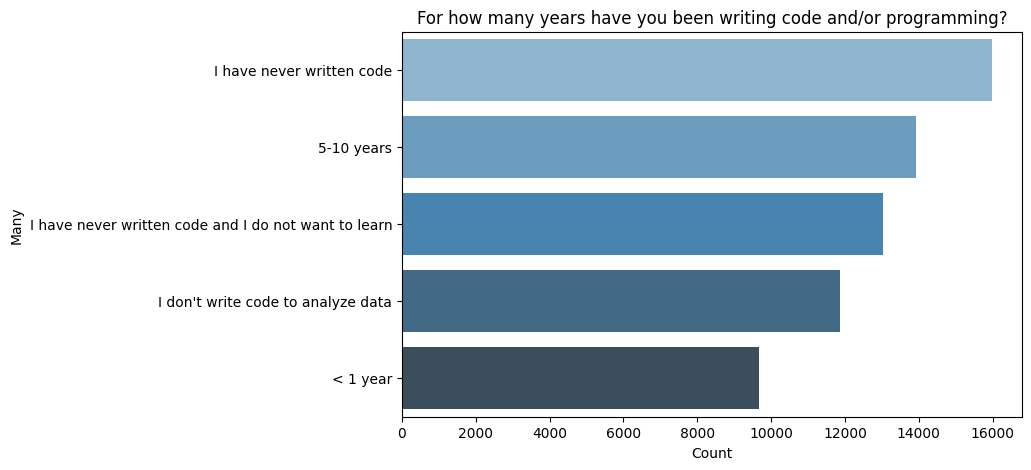

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

code_col = [col for col in df_restored.columns if 'Q6' in col]
code_langs = langs.value_counts().head(5)

plt.figure(figsize=(8,5))
sns.barplot(x=code_langs.values, y=code_langs.index, palette="Blues_d")
plt.title("For how many years have you been writing code and/or programming?")
plt.xlabel("Count")
plt.ylabel("Many")
plt.show()

C:\Users\ziyad\AppData\Local\Temp\ipykernel_4164\2698655797.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=job_counts.values, y=job_counts.index, palette="Greens_d")


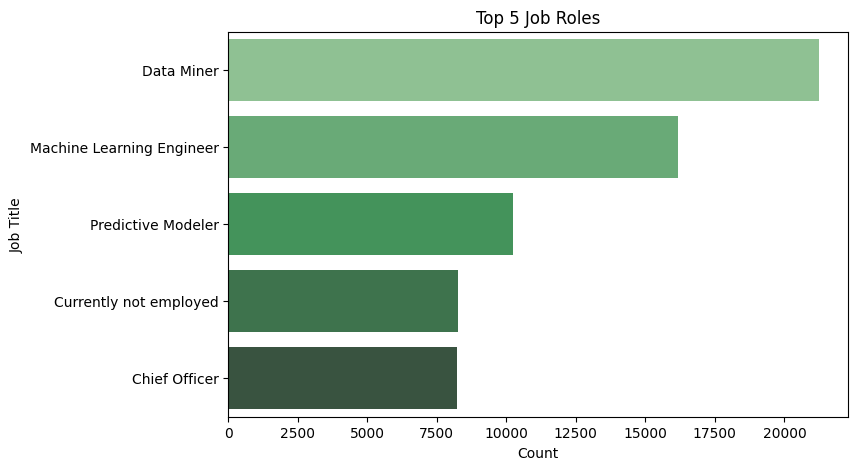

In [59]:
job_counts = df_restored['Q5'].value_counts().head(5)

plt.figure(figsize=(8,5))
sns.barplot(x=job_counts.values, y=job_counts.index, palette="Greens_d")
plt.title("Top 5 Job Roles")
plt.xlabel("Count")
plt.ylabel("Job Title")
plt.show()

C:\Users\ziyad\AppData\Local\Temp\ipykernel_4164\2796651369.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_counts.values, y=country_counts.index, palette="Purples_d")


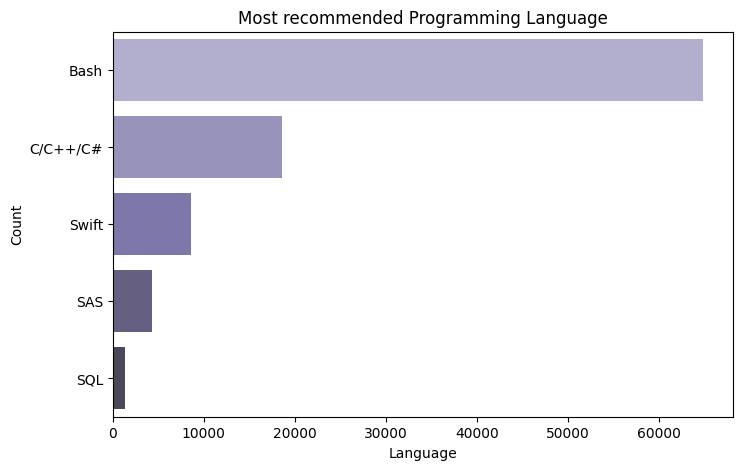

In [74]:
country_counts = df_restored['Q8'].value_counts().head(5)

plt.figure(figsize=(8,5))
sns.barplot(x=country_counts.values, y=country_counts.index, palette="Purples_d")
plt.title("Most recommended Programming Language")
plt.xlabel("Language")
plt.ylabel("Count")
plt.show()


In [75]:
output_path = "cleaned_kaggle_survey_data.csv"
df.to_csv(output_path, index=False)
print(f"✅ Cleaned dataset saved successfully as: {output_path}")

✅ Cleaned dataset saved successfully as: cleaned_kaggle_survey_data.csv
